<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

In [1]:
# !gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO # sound_classification_dataset.zip
# !gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT # train.csv
# !gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 # valid.csv
# !gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks # test.csv

Разархивируйте zip файл, где содержатся wav файлы датасета.

In [2]:
# !ls

In [3]:
# !unzip ./content/sound_classification_dataset.zip

In [4]:
import pandas as pd
import torch
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings("ignore")

In [5]:
train_df = pd.read_csv("content/train.csv")
valid_df = pd.read_csv("content/valid.csv")
test_df = pd.read_csv("content/test.csv")

In [6]:
train_df.info

<bound method DataFrame.info of               filename     category
0     1-100032-A-0.wav          dog
1     1-110389-A-0.wav          dog
2     1-17367-A-10.wav         rain
3    1-187207-A-20.wav  crying_baby
4    1-211527-A-20.wav  crying_baby
..                 ...          ...
115  3-170383-A-38.wav   clock_tick
116  3-171012-A-38.wav   clock_tick
117  3-171041-A-38.wav   clock_tick
118   3-180256-A-0.wav          dog
119   3-180977-A-0.wav          dog

[120 rows x 2 columns]>

In [7]:
train_df.groupby('category').count()

,filename
category,
clock_tick,24
crying_baby,24
dog,24
rain,24
sneezing,24


Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
device

device(type='cpu')

In [10]:

import torchaudio
from torch.utils.data import Dataset
import pandas as pd
import os
import random
import math

class SimpleAudioDataset(Dataset):
    """
    WAV-only датасет:
      - resample -> 16000 Hz
      - stereo -> mono
      - нормализация амплитуды к [-1, 1]
      - приведение длины к фиксированной (обрезка/паддинг)
      - опциональные аугментации (только в train)
    Ожидаемые колонки:
      - путь к файлу: одна из ['path','filepath','wav_path','filename']
      - метка (train/valid): 'category'
    """
    def __init__(
        self,
        df,
        target_sr=16000,
        length_seconds=4.0,
        do_augmentation=False,
        label_encoder=None,
        data_dir=None,
        classes=None,   # 👈 добавляем
    ):
        self.df = df.reset_index(drop=True)
        self.target_sr = target_sr
        self.length_samples = int(length_seconds * target_sr)
        self.do_augmentation = do_augmentation
        self.label_encoder = label_encoder
        self.data_dir = data_dir

        # 👇 сохраняем список классов, если есть
        if label_encoder is not None:
            self.classes = list(label_encoder.classes_)
        else:
            self.classes = list(classes) if classes is not None else None
        # autodetect path column
        path_cols = ['path', 'filepath', 'wav_path', 'filename']
        self.path_col = None
        for c in path_cols:
            if c in self.df.columns:
                self.path_col = c
                break
        if self.path_col is None:
            raise ValueError(f"Не найден столбец пути среди {path_cols}")
        self.has_label = 'category' in self.df.columns
        self._resamplers = {}

    def __len__(self):
        return len(self.df)

    def _load_wav(self, path: str):
        # torchaudio.load -> (channels, n_samples), sample_rate
        waveform, sr = torchaudio.load(path)
        # float32 в [-1,1] обычно уже норм, но на всякий случай приведём к float32
        if waveform.dtype != torch.float32:
            waveform = waveform.to(torch.float32)
        return waveform, sr

    def _stereo_to_mono(self, signal: torch.Tensor):
        # (C, T) -> (1, T), усредняем каналы
        if signal.dim() == 2 and signal.size(0) > 1:
            signal = signal.mean(dim=0, keepdim=True)
        return signal

    def _resample(self, signal: torch.Tensor, orig_sr: int):
        if orig_sr == self.target_sr:
            return signal
        key = (orig_sr, self.target_sr)
        if key not in self._resamplers:
            self._resamplers[key] = torchaudio.transforms.Resample(orig_sr, self.target_sr)
        return self._resamplers[key](signal)

    def _normalize(self, signal: torch.Tensor, eps: float = 1e-9):
        # нормализуем к [-1,1] по максимальному |амплитуде|
        peak = signal.abs().max()
        if float(peak) > eps:
            signal = signal / peak
        return signal

    def _cut_or_pad(self, signal: torch.Tensor):
        # signal: (1, T)
        T = signal.size(-1)
        L = self.length_samples
        if T == L:
            return signal
        if T > L:
            # центрированная обрезка (можно и слева, и справа — не критично)
            start = (T - L) // 2
            return signal[..., start:start+L]
        # T < L -> паддинг нулями
        pad_left = (L - T) // 2
        pad_right = L - T - pad_left
        return torch.nn.functional.pad(signal, (pad_left, pad_right))

    # --- простые аугментации на волне (без спектров) ---
    def _augment(self, signal: torch.Tensor):
        # вероятность каждой аугментации невелика — комбинируем
        if random.random() < 0.5:
            # случайный gain в пределах ~±6 дБ
            db = random.uniform(-6.0, 6.0)
            gain = 10.0 ** (db / 20.0)
            signal = signal * gain

        if random.random() < 0.4:
            # случайный temporal shift (circular roll) до ±10% длины
            T = signal.size(-1)
            max_shift = int(0.1 * T)
            if max_shift > 0:
                shift = random.randint(-max_shift, max_shift)
                signal = torch.roll(signal, shifts=shift, dims=-1)

        if random.random() < 0.4:
            # слабый белый шум SNR ~ 20–30 дБ
            noise_std = signal.std().item() * random.uniform(0.02, 0.1)
            if noise_std > 0:
                noise = torch.randn_like(signal) * noise_std
                signal = signal + noise

        # ограничим по амплитуде на всякий случай
        signal = torch.clamp(signal, -1.0, 1.0)
        return signal

    def __getitem__(self, index: int):
        row = self.df.iloc[index]
        fname = row[self.path_col]
    
        # 👇 если задан data_dir, соединяем его с именем файла
        if self.data_dir is not None:
            path = os.path.join(self.data_dir, fname)
        else:
            path = fname
    
        if not os.path.isabs(path):
            path = os.path.abspath(path)
    
        signal, sr = self._load_wav(path)

        signal, sr = self._load_wav(path)
        signal = self._stereo_to_mono(signal)
        signal = self._resample(signal, sr)
        signal = self._normalize(signal)
        signal = self._cut_or_pad(signal)

        if self.do_augmentation:
            signal = self._augment(signal)

        # Итоговая форма: (1, L)
        if self.has_label:
            y = row['category']
            if self.label_encoder is not None:
                y = self.label_encoder.transform([y])[0]
            y = int(y)
            return signal, y
        else:
            return signal


In [11]:
class AugRepeatDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds, repeat=5):
        self.base = base_ds
        self.repeat = repeat
    def __len__(self):
        return len(self.base) * self.repeat
    def __getitem__(self, i):
        return self.base[i % len(self.base)]

In [12]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
import torch.optim as optim
import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# 1) LabelEncoder по train
if 'category' not in train_df.columns:
    raise ValueError("В train.csv должна быть колонка 'category'.")

le = LabelEncoder()
le.fit(train_df['category'].values)

num_classes = len(le.classes_)
print("Classes:", list(le.classes_))
print("num_classes:", num_classes)

Classes: ['clock_tick', 'crying_baby', 'dog', 'rain', 'sneezing']
num_classes: 5


In [13]:


TARGET_SR = 16000
LENGTH_SECONDS = 4.0
BATCH_SIZE = 32
NUM_WORKERS = 2
DATA_DIR = 'content/sound_classification_dataset/'
train_ds = SimpleAudioDataset(
    train_df,
    target_sr=TARGET_SR,
    length_seconds=LENGTH_SECONDS,
    do_augmentation=True,
    label_encoder=le,
    data_dir=DATA_DIR        # 👈 добавляем сюда!
)
valid_ds = SimpleAudioDataset(
    valid_df,
    target_sr=TARGET_SR,
    length_seconds=LENGTH_SECONDS,
    do_augmentation=False,
    label_encoder=le,
    data_dir=DATA_DIR        # 👈 тоже сюда
)

train_ds_aug = AugRepeatDataset(train_ds, repeat=10) # 👈 аугментация

train_loader = DataLoader(
    train_ds_aug, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, persistent_workers=True,
    prefetch_factor=2, pin_memory=True, drop_last=False
)
valid_loader = DataLoader(
    valid_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, persistent_workers=True,
    prefetch_factor=2, pin_memory=True, drop_last=False
)


In [14]:
import time, itertools
t0 = time.time()
for i, (x, y) in zip(range(50), train_loader):   # 50 шагов = 1 эпоха
    pass
print("epoch time:", time.time() - t0, "sec") 

RuntimeError: DataLoader worker (pid(s) 3708, 10332) exited unexpectedly

In [ ]:
xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape) 

torch.Size([32, 1, 64000]) torch.Size([32])


### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

In [ ]:
import torch.nn as nn

class SoundClassificatonModel(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=9, stride=1, padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(32, 64, kernel_size=9, stride=1, padding=4),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(64, 128, kernel_size=9, stride=1, padding=4),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=4, stride=4),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (B, 1, L)
        x = self.features(x)
        # global average pooling по времени
        x = x.mean(dim=-1)           # (B, 128)
        x = self.classifier(x)       # (B, C)
        return x


In [ ]:
model =  SoundClassificatonModel(num_classes=5).to(device)

### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [ ]:
import wandb
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR, MultiStepLR, SequentialLR
# --- 1. Инициализация wandb ---
wandb.init(
    project="sound_classification_wav2",
    name="cnn_waveform_run3",
    config={
        "target_sr": TARGET_SR,
        "length_seconds": LENGTH_SECONDS,
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "epochs": 15,
        "optimizer": "AdamW",
        "lr": 2e-3,
        "model": "SoundClassificatonModel",
    },
)
optimizer = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4, betas=(0.9, 0.99))
# --- 2. Цикл обучения ---
EPOCHS = 100
best_acc = 0.0
train_losses, train_accs = [], []
valid_losses, valid_accs = [], []
WARMUP_EPOCHS = 3           # 2–5 обычно ок для такого LR и BATCH_SIZE
MILESTONES = [
    int(0.40 * EPOCHS),     # первая ступень
    int(0.70 * EPOCHS),     # вторая
    int(0.85 * EPOCHS),     # третья
]
GAMMA = 0.5                 # во столько раз уменьшаем LR на каждой ступени

def warmup_lambda(epoch):
    # линейный разгон LR от 0 -> 1 за WARMUP_EPOCHS
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(max(1, WARMUP_EPOCHS))
    return 1.0

warmup_scheduler   = LambdaLR(optimizer, lr_lambda=warmup_lambda)
decay_scheduler    = MultiStepLR(optimizer, milestones=MILESTONES, gamma=GAMMA)

# Комбинируем: сначала warmup, затем ступени
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, decay_scheduler],
                         milestones=[WARMUP_EPOCHS])

def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss, tr_acc, tr_n = 0.0, 0.0, 0

    pbar = tqdm(train_loader, desc=f"Train {epoch}/{EPOCHS}")
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        acc = accuracy_from_logits(logits, yb)
        tr_loss += loss.item() * yb.size(0)
        tr_acc  += acc * yb.size(0)
        tr_n    += yb.size(0)

        pbar.set_postfix(loss=loss.item(), acc=acc)
    train_loss = tr_loss / tr_n
    train_acc = tr_acc / tr_n
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # --- Validation ---
    model.eval()
    va_loss, va_acc, va_n = 0.0, 0.0, 0
    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            acc = accuracy_from_logits(logits, yb)

            va_loss += loss.item() * yb.size(0)
            va_acc  += acc * yb.size(0)
            va_n    += yb.size(0)

    valid_loss = va_loss / va_n
    valid_acc = va_acc / va_n
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)

    scheduler.step()

    # --- 3. wandb логирование ---
    wandb.log({
        "epoch": epoch,
        "train/loss": train_loss,
        "train/acc": train_acc,
        "valid/loss": valid_loss,
        "valid/acc": valid_acc,
        "lr": scheduler.get_last_lr()[0],
    })
    
    print(f"Epoch {epoch:02d} | "
          f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"valid_loss={valid_loss:.4f} acc={valid_acc:.4f}")

    # --- 4. Сохранение лучшего чекпоинта ---
    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(
            {
                "model_state": model.state_dict(),
                "classes": list(le.classes_),
                "valid_acc": best_acc,
            },
            "best_wave_cnn.pth",
        )
        print(f">> Saved best checkpoint (valid_acc={best_acc:.4f})")
        wandb.run.summary["best_valid_acc"] = best_acc

    


Train 1/100:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.9675 acc=0.6450 | valid_loss=1.3591 acc=0.4250
>> Saved best checkpoint (valid_acc=0.4250)


Train 2/100:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.6630 acc=0.7742 | valid_loss=0.8462 acc=0.6000
>> Saved best checkpoint (valid_acc=0.6000)


Train 3/100:   0%|          | 0/38 [00:00<?, ?it/s]

...

Epoch 86 | train_loss=0.0384 acc=0.9883 | valid_loss=0.6365 acc=0.8750


Train 87/100:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 87 | train_loss=0.0328 acc=0.9883 | valid_loss=0.6069 acc=0.8250


Train 88/100:   0%|          | 0/38 [00:00<?, ?it/s]

KeyboardInterrupt: 

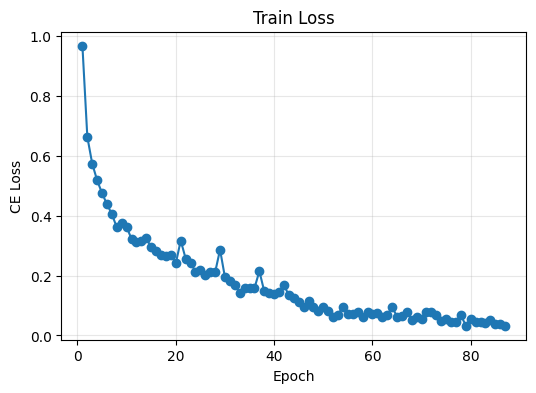

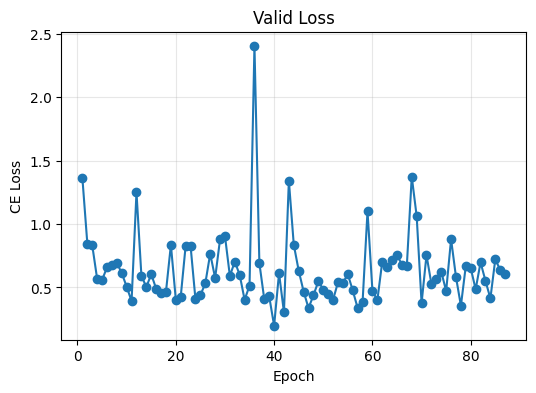

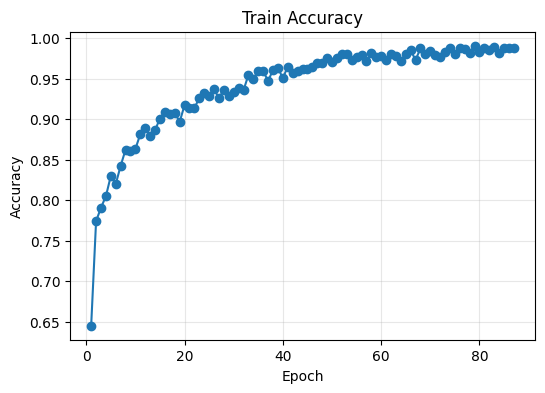

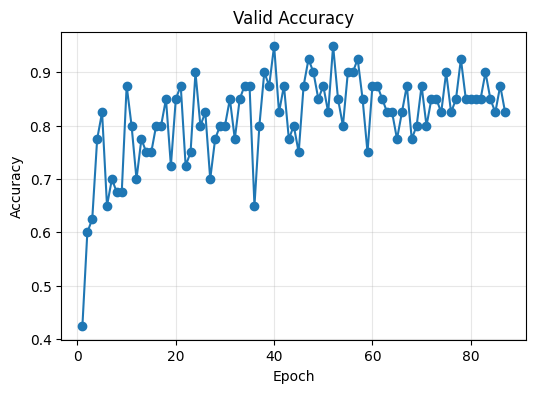

Train Accuracy =  0.9908333333333333
Valid Accuracy =  0.95


In [ ]:
def plot_pairs(xs, ys, title, xlab, ylab):
        plt.figure(figsize=(6,4))
        plt.plot(xs, ys, marker='o')
        plt.title(title)
        plt.xlabel(xlab); plt.ylabel(ylab)
        plt.grid(True, alpha=0.3)
        plt.show()

plot_pairs(range(1, len(train_losses)+1), train_losses, "Train Loss", "Epoch", "CE Loss")
plot_pairs(range(1, len(valid_losses)+1), valid_losses, "Valid Loss", "Epoch", "CE Loss")
plot_pairs(range(1, len(train_accs)+1), train_accs, "Train Accuracy", "Epoch", "Accuracy")
plot_pairs(range(1, len(valid_accs)+1), valid_accs, "Valid Accuracy", "Epoch", "Accuracy")
print("Train Accuracy = ",max(train_accs))
print("Valid Accuracy = ", max(valid_accs))

In [ ]:
wandb.finish()

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
lr,▅███████████████████▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▁▁▁▁▁
train/acc,▁▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇█▇█▇▇████████████████
train/loss,█▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
valid/acc,▁▄▇▅▇▆▆▆▅▇▆▆▇▅▆▇▇▆█▇▆█▇▆█▇▆▇▆▆▇▇█▇▇▇▇▇█▇
valid/loss,▅▃▂▃▂▂▂▂▃▂▂▂▃▂▂█▃▂▁▂▅▃▂▂▂▂▂▂▂▃▂▅▂▂▂▂▂▂▃▂
best_valid_acc,0.95
epoch,87
lr,0.0005
train/acc,0.98833
train/loss,0.03277


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

Using device: cuda
ESC-50 Audio Classification Demo!


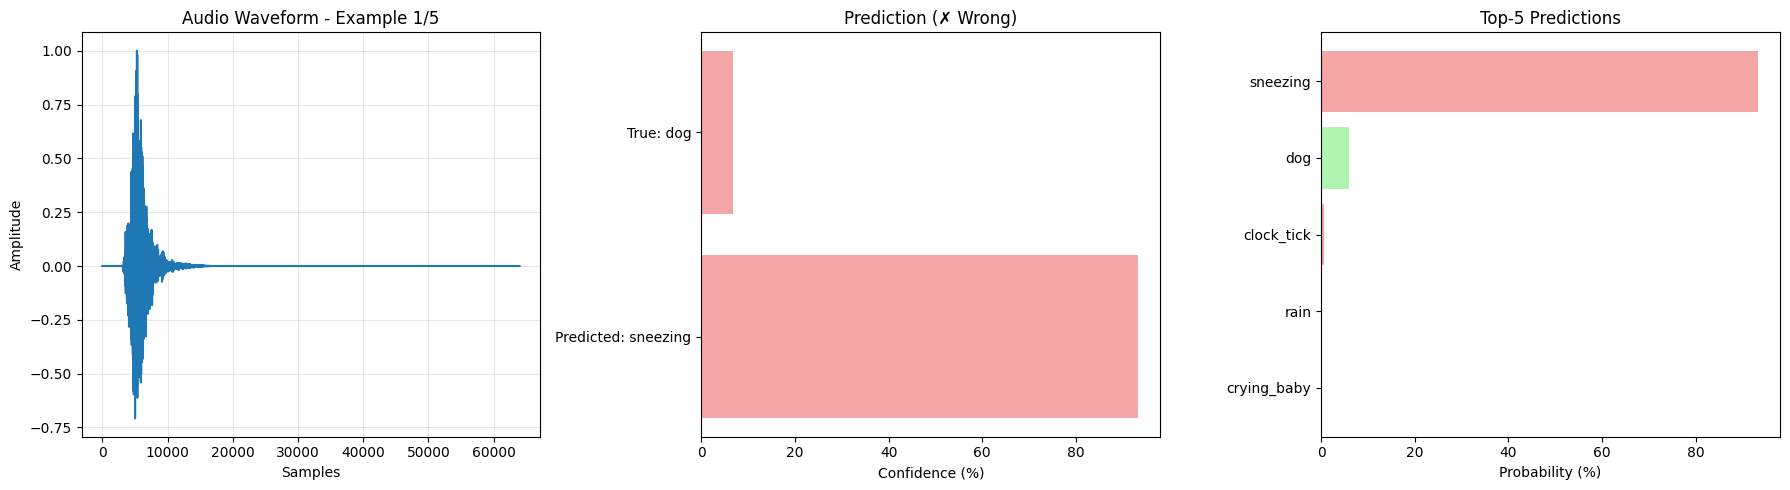

Playing: dog


Prediction: sneezing (93.34%)
True label: dog
Correct: False


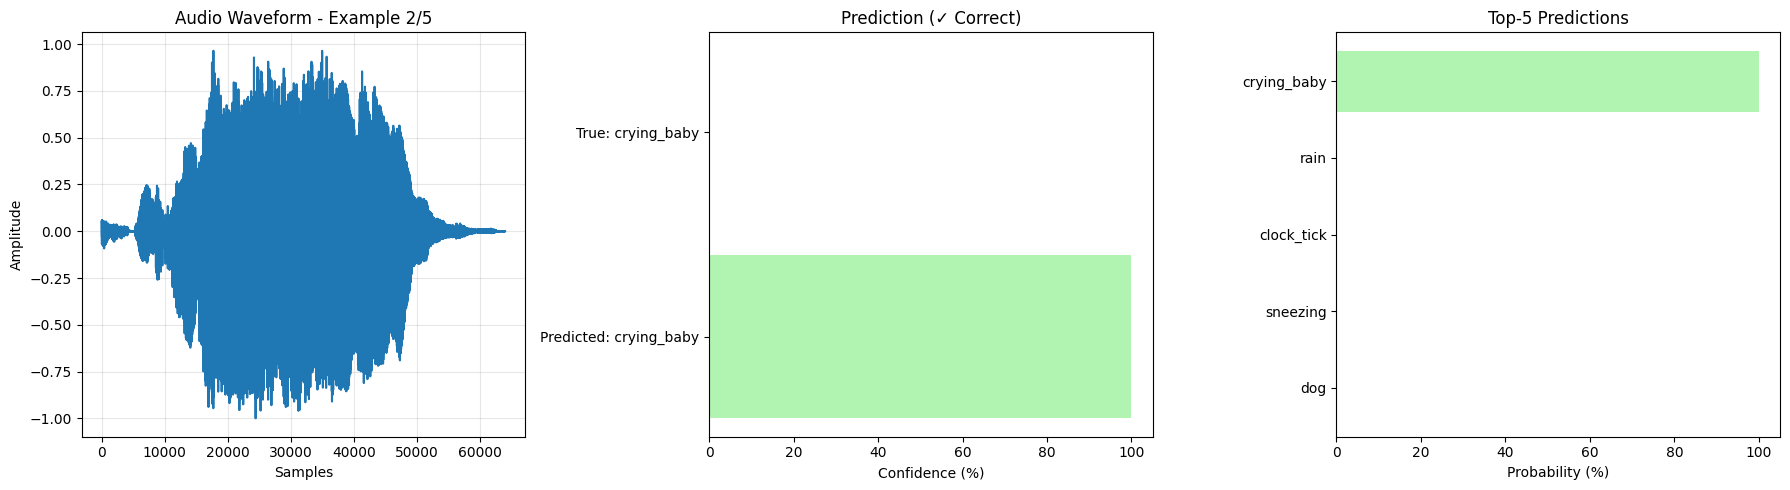

Playing: crying_baby


Prediction: crying_baby (100.00%)
True label: crying_baby
Correct: True


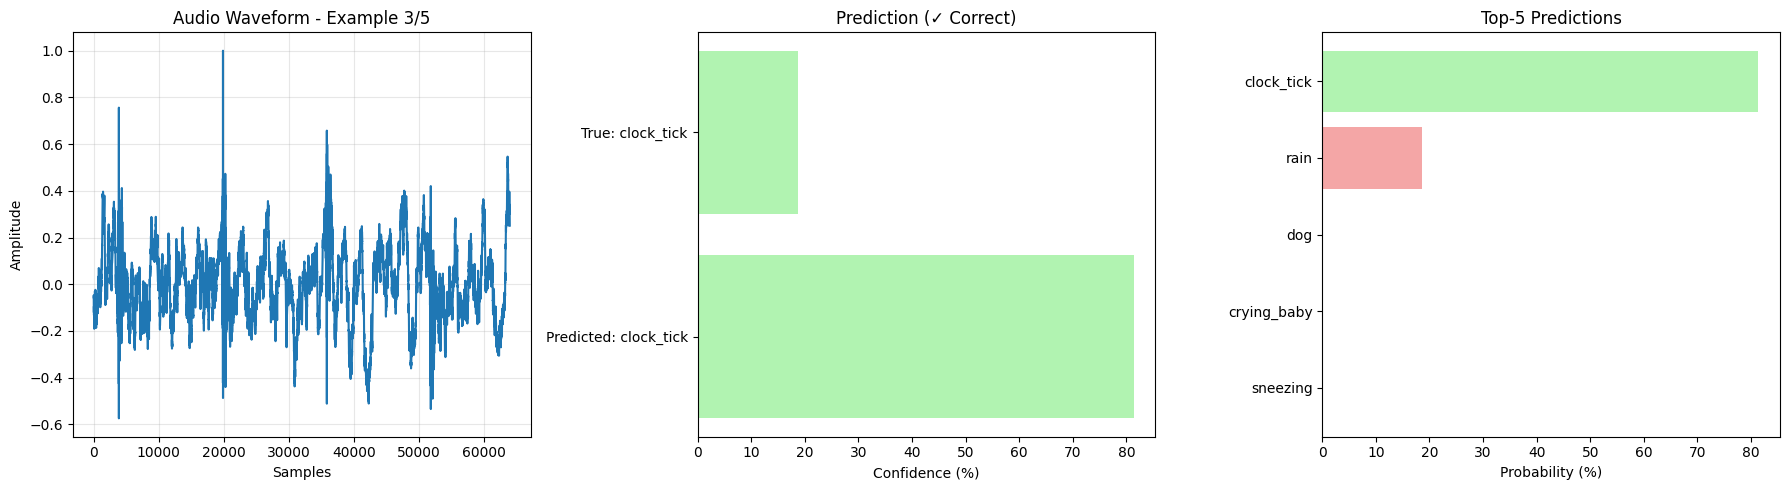

Playing: clock_tick


Prediction: clock_tick (81.33%)
True label: clock_tick
Correct: True


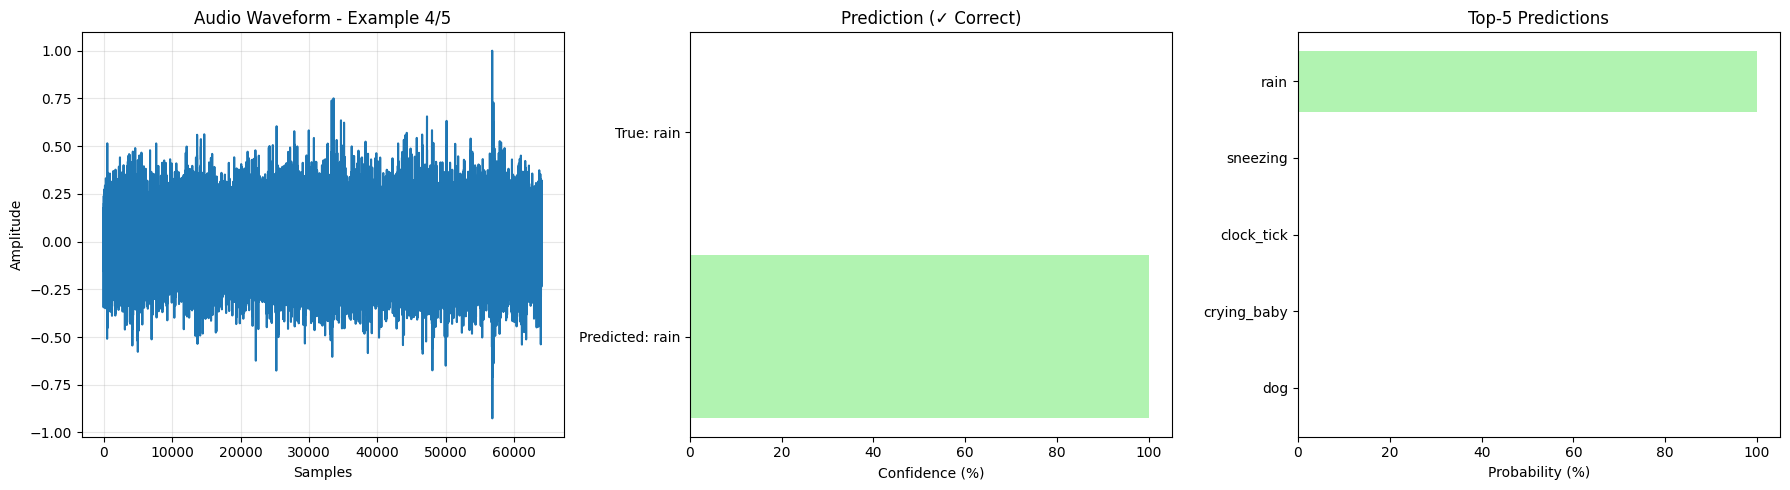

Playing: rain


Prediction: rain (100.00%)
True label: rain
Correct: True


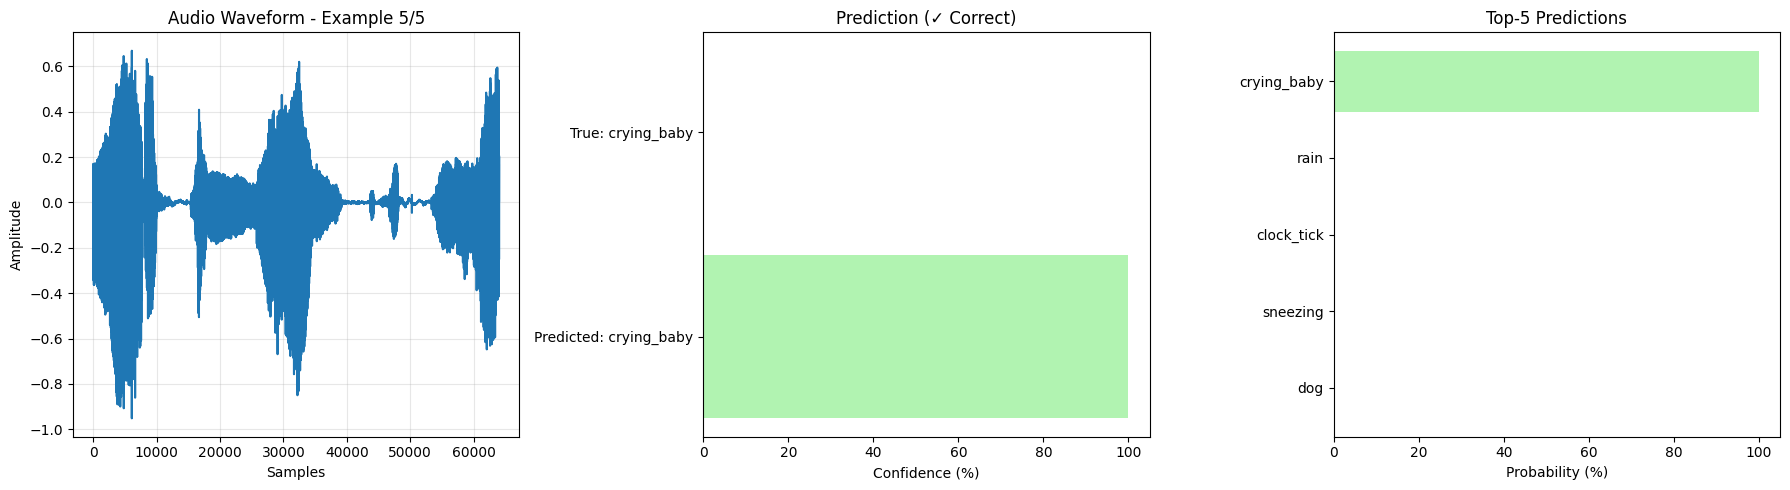

Playing: crying_baby


Prediction: crying_baby (100.00%)
True label: crying_baby
Correct: True
ESC-50 Test Set Evaluation (Fold 5):
Correct: 34/40
Accuracy: 85.00%


In [ ]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.classes
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_ds , device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [ ]:
# Инференс на test_df: получаем y_test_pred в исходных классах (label names)
from tqdm.auto import tqdm
import numpy as np
import torch, os

# 1) Делаем датасет именно из test_df (без меток и без аугментаций!)
test_ds = SimpleAudioDataset(
    test_df,
    target_sr=TARGET_SR,
    length_seconds=LENGTH_SECONDS,
    do_augmentation=False,
    label_encoder=None,              # <- важно: тест без label_encoder
    data_dir=DATA_DIR,
    classes=list(le.classes_),       # чтобы demo знало имена классов, если нужно
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    persistent_workers=True,
    prefetch_factor=2,
    pin_memory=True,
    drop_last=False,
)

# 2) Загружаем лучший чекпоинт
ckpt_path = "best_wave_cnn.pth"
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    print("Loaded best checkpoint.")

# 3) Предсказания
model.eval()
pred_indices = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predict test"):
        # batch — это ТОЛЬКО аудио (без меток), но на всякий случай:
        xb = batch[0] if isinstance(batch, (list, tuple)) else batch
        if isinstance(xb, list):              # если collate вернул список тензоров
            xb = torch.stack(xb)
        xb = xb.to(device)

        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        pred_indices.extend(preds)

# 4) Индексы -> имена классов
y_test_pred = le.inverse_transform(np.array(pred_indices))
print("Predicted", len(y_test_pred), "samples, expected", len(test_df))


Loaded best checkpoint.


Predict test:   0%|          | 0/2 [00:00<?, ?it/s]

Predicted 40 samples, expected 40


In [ ]:
submission = pd.read_csv("test.csv")
submission["category"] = y_test_pred
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv:", submission.shape)

Saved submission.csv: (40, 2)


### **Report**

Опишите ваш путь экспериментов и что вы сделали, чтобы получить наилучшую модель.

#### Написал модель,  проверенный вариант по образцу сверточных декодеров. -> 
#### получил какието метрики приемлимые -> 
#### добавил аугментацию (cм класс датасета , шум , громкость , темп ) ->
#### поставил шедуллир на learning rate и перезапустил . -> 
#### профит
wandb: https://wandb.ai/anv-a-b-mai/sound_classification_wav2/workspace?nw=nwuseranvabmai

Saved submission.csv: (40, 2)
